,ERP-A,ERP-B,ERP-C,ERP-D
Functional coverage,5,4,3,4
Implementation feasibility,3,4,5,3
Scalability,4,3,3,5
Usability,4,3,4,3
Integration capability,4,4,3,4
Vendor support reliability,5,4,3,4


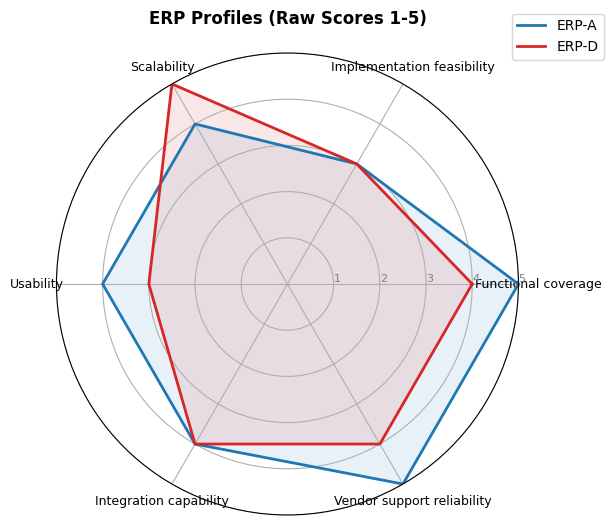

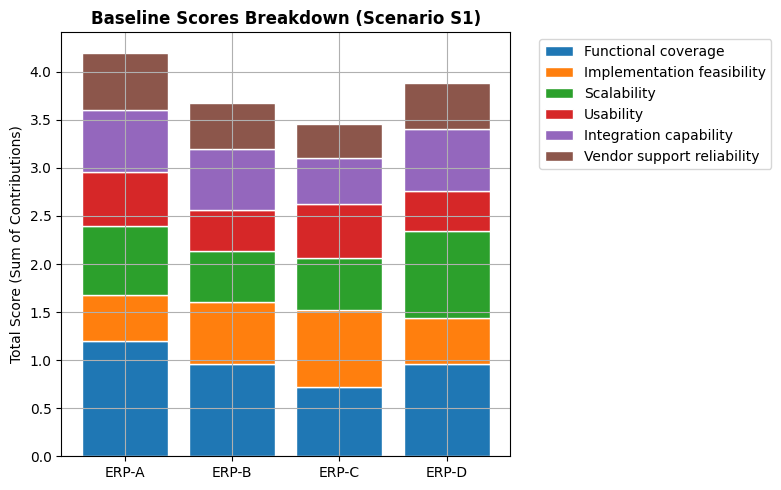

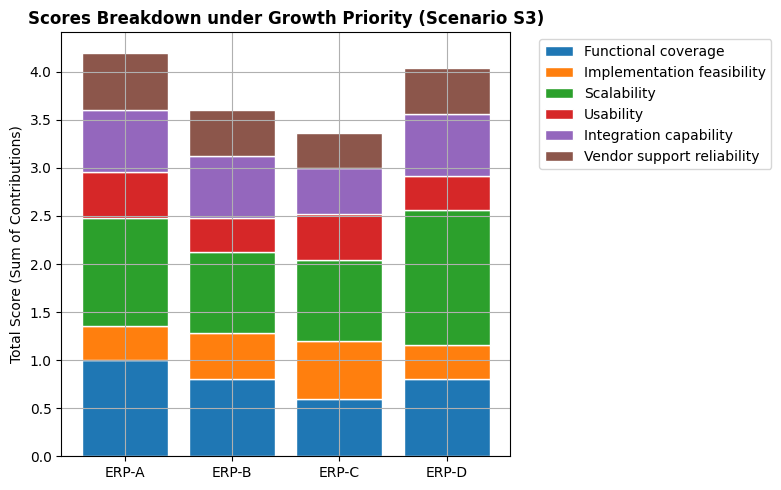

In [7]:
# ================================================================
# Automated, Explainable MCDA-based ERP Pre-Selection (Simulation)
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi
from IPython.display import display, HTML, clear_output

# Interactivitate
try:
    from ipywidgets import interact, FloatSlider, Dropdown, HBox, VBox, Button, Output, Layout
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

plt.rcParams.update({"figure.figsize":(8, 5), "axes.grid":True, "font.size": 10})

# Setăm culori fixe pentru criterii (pentru a fi consecvenți în grafice)
CRIT_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# ------------------------------------------------
# 1) Datele experimentului
# ------------------------------------------------
alts = ["ERP-A", "ERP-B", "ERP-C", "ERP-D"]
criteria = [
    "Functional coverage", "Implementation feasibility", "Scalability",
    "Usability", "Integration capability", "Vendor support reliability"
]

# Note brute (1-5) - Table 2
scores = {
    "ERP-A":[5, 3, 4, 4, 4, 5],
    "ERP-B":[4, 4, 3, 3, 4, 4],
    "ERP-C":[3, 5, 3, 4, 3, 3],
    "ERP-D":[4, 3, 5, 3, 4, 4]
}

# Ponderi scenarii - Table 1 & 4
weights = {
    "S1": [0.24, 0.16, 0.18, 0.14, 0.16, 0.12], # Baseline (Balanced)
    "S2": [0.20, 0.25, 0.15, 0.14, 0.14, 0.12], # Feasibility-oriented
    "S3": [0.20, 0.12, 0.28, 0.12, 0.16, 0.12]  # Growth-oriented
}

scores_df  = pd.DataFrame(scores,  index=criteria)
weights_df = pd.DataFrame(weights, index=criteria)

# ------------------------------------------------
# 2) Funcții Core MCDA & Generare Text (NLG)
# ------------------------------------------------
def run_mcda(w_vec, scores_dict, alt_list, crit_list):
    w_vec = list(w_vec)
    k = len(crit_list)
    # Calcul scor total
    score = {a: sum(w_vec[j] * scores_dict[a][j] for j in range(k)) for a in alt_list}
    ranking = sorted(score.items(), key=lambda x: x[1], reverse=True)
    winner, wscore = ranking[0]
    runner, rscore = ranking[1]
    margin = wscore - rscore
    # Calcul contribuții per criteriu (c_ij = w_j * s_ij)
    contrib = {a: [w_vec[j]*scores_dict[a][j] for j in range(k)] for a in alt_list}
    return score, ranking, winner, runner, margin, contrib

def generate_explanation(ranking, margin, contrib, winner, criteria):
    # Găsim top 2 criterii care au contribuit la victoria câștigătorului
    win_contribs = contrib[winner]
    top_indices = sorted(range(len(win_contribs)), key=lambda i: win_contribs[i], reverse=True)[:2]
    top_crit_1, top_crit_2 = criteria[top_indices[0]], criteria[top_indices[1]]

    text = (f"<b>Automated Explanation:</b> The recommended alternative is <b>{winner}</b> "
            f"with a total score of {ranking[0][1]:.2f}. It outperforms the runner-up, {ranking[1][0]}, "
            f"by a margin of {margin:.2f} points. The top position of {winner} is primarily driven by its "
            f"strong contributions in <i>{top_crit_1}</i> and <i>{top_crit_2}</i>.")
    return text

def normalize_w(vec):
    s = sum(vec)
    return [v/s for v in vec] if s > 0 else vec

# ------------------------------------------------
# 3) Vizualizări: Radar Chart & Stacked Bar
# ------------------------------------------------
def plot_radar(scores_dict, criteria, alts_to_plot=["ERP-A", "ERP-D"]):
    # Grafic Radar pentru notele brute (1-5)
    N = len(criteria)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # închidem cercul

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], criteria, size=9)
    ax.set_rlabel_position(0)
    plt.yticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"], color="grey", size=8)
    plt.ylim(0, 5)

    colors = ['#1f77b4', '#d62728', '#2ca02c']
    for i, alt in enumerate(alts_to_plot):
        values = scores_dict[alt]
        values += values[:1] # închidem cercul
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=alt, color=colors[i%len(colors)])
        ax.fill(angles, values, color=colors[i%len(colors)], alpha=0.1)

    plt.title("ERP Profiles (Raw Scores 1-5)\n", size=12, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.show()

def plot_stacked_bar(contrib, criteria, alts, title="MCDA Scores Breakdown"):
    # Grafic Stacked Bar pentru contribuții (arată din ce e compus scorul)
    fig, ax = plt.subplots(figsize=(8, 5))
    bottom = np.zeros(len(alts))

    for i, crit in enumerate(criteria):
        values = [contrib[a][i] for a in alts]
        ax.bar(alts, values, bottom=bottom, label=crit, color=CRIT_COLORS[i], edgecolor='white')
        bottom += np.array(values)

    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("Total Score (Sum of Contributions)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ================================================================
# AFIȘARE REZULTATE STATICE (Prezentarea datelor din articol)
# ================================================================
display(HTML("<h2>1. Simulation Dataset & ERP Profiles</h2>"))
display(scores_df)
plot_radar(scores, criteria, ["ERP-A", "ERP-D"])

display(HTML("<h2>2. Baseline Scenario (S1: Balanced)</h2>"))
_, rk_s1, win_s1, run_s1, m_s1, ctb_s1 = run_mcda(weights["S1"], scores, alts, criteria)
plot_stacked_bar(ctb_s1, criteria, alts, "Baseline Scores Breakdown (Scenario S1)")
display(HTML(generate_explanation(rk_s1, m_s1, ctb_s1, win_s1, criteria)))

display(HTML("<h2>3. Sensitivity Analysis (Scenario S3: Growth-oriented)</h2>"))
_, rk_s3, win_s3, run_s3, m_s3, ctb_s3 = run_mcda(weights["S3"], scores, alts, criteria)
plot_stacked_bar(ctb_s3, criteria, alts, "Scores Breakdown under Growth Priority (Scenario S3)")
display(HTML(generate_explanation(rk_s3, m_s3, ctb_s3, win_s3, criteria)))

# ================================================================
# 4. DASHBOARD INTERACTIV (Decision Support System)
# ================================================================
if HAS_WIDGETS:
    display(HTML("<hr><h2>4. Interactive DSS Dashboard</h2>"))
    display(HTML("<p>Move the sliders to change criterion weights, or click the preset buttons to load article scenarios.</p>"))

    # UI Elements
    sliders = [FloatSlider(value=weights["S1"][i], min=0.0, max=0.5, step=0.01,
                           description=crit.split()[0]+":", layout=Layout(width='300px')) for i, crit in enumerate(criteria)]

    btn_s1 = Button(description="Load S1 (Balanced)", button_style='info')
    btn_s2 = Button(description="Load S2 (Feasibility)", button_style='warning')
    btn_s3 = Button(description="Load S3 (Growth)", button_style='success')
    out = Output()

    # Logica de update interactiv
    def update_dashboard(*args):
        w_curr = normalize_w([sl.value for sl in sliders])
        sc, rk, win, run, m, ctb = run_mcda(w_curr, scores, alts, criteria)

        with out:
            clear_output(wait=True)
            plot_stacked_bar(ctb, criteria, alts, "Live MCDA Scores Breakdown")
            display(HTML(generate_explanation(rk, m, ctb, win, criteria)))

            # Afișăm și un tabel mic cu rezultatele
            df_res = pd.DataFrame({"Score": [s for a,s in rk]}, index=[a for a,s in rk])
            display(df_res.T)

    # Logica butoanelor preset
    def load_preset(scenario_key):
        for i, val in enumerate(weights[scenario_key]):
            sliders[i].value = val

    btn_s1.on_click(lambda x: load_preset("S1"))
    btn_s2.on_click(lambda x: load_preset("S2"))
    btn_s3.on_click(lambda x: load_preset("S3"))

    for sl in sliders:
        sl.observe(update_dashboard, names='value')

    # Layout
    ui_buttons = HBox([btn_s1, btn_s2, btn_s3])
    ui_sliders = VBox(sliders)
    display(VBox([ui_buttons, ui_sliders, out]))
    update_dashboard() # rulare inițială
else:
    print("\n(Interactive widgets not supported in this environment)")